# Engagement vs Views Analysis

## Import Libraries


In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Load Data

In [13]:
df = pd.read_csv("raw.csv")
df.head()

,post_id,platform,content_type,topic,language,region,post_datetime,hashtags,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
0,SM_100000,Instagram,text,Sports,ur,UK,2024-12-10 00:00:00,#tech #funny #music,2319102,122058,15800,861,0.0598,0.464,1
1,SM_100001,Instagram,carousel,Sports,ur,Brazil,2024-10-13 00:00:00,#news #fyp #funny #ai #trending,2538464,110368,11289,54887,0.0695,-0.800,1
2,SM_100002,YouTube Shorts,video,Technology,ur,UK,2024-05-03 00:00:00,#ai #news,1051176,87598,47196,44132,0.1702,0.416,0
3,SM_100003,X,text,Politics,ur,US,2024-08-04 00:00:00,#ai #funny,5271440,329465,774,59736,0.0740,0.877,1
4,SM_100004,YouTube Shorts,text,Education,es,US,2024-03-28 00:00:00,#news #ai #viral #funny #fyp,3186256,199141,5316,83105,0.0903,0.223,1


## Basic Data Inspection

In [14]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          2000 non-null   str    
 1   platform         2000 non-null   str    
 2   content_type     2000 non-null   str    
 3   topic            2000 non-null   str    
 4   language         2000 non-null   str    
 5   region           2000 non-null   str    
 6   post_datetime    2000 non-null   str    
 7   hashtags         2000 non-null   str    
 8   views            2000 non-null   int64  
 9   likes            2000 non-null   int64  
 10  comments         2000 non-null   int64  
 11  shares           2000 non-null   int64  
 12  engagement_rate  2000 non-null   float64
 13  sentiment_score  2000 non-null   float64
 14  is_viral         2000 non-null   int64  
dtypes: float64(2), int64(5), str(8)
memory usage: 234.5 KB


,views,likes,comments,shares,engagement_rate,sentiment_score,is_viral
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4.284860e+06,245329.244000,24786.929000,49936.981500,0.157852,-0.000566,0.699000
std,3.246193e+06,145032.423582,14433.288364,29012.818697,0.535457,0.574911,0.458807
min,4.380000e+03,292.000000,14.000000,127.000000,0.035700,-1.000000,0.000000
25%,1.652742e+06,118903.750000,12337.750000,25698.750000,0.057975,-0.507000,0.000000
50%,3.469408e+06,239831.000000,24519.500000,50212.000000,0.084500,0.001000,1.000000
75%,6.348078e+06,372323.500000,37116.250000,75433.000000,0.142525,0.495250,1.000000
max,1.437179e+07,499983.000000,49989.000000,99977.000000,12.573200,0.999000,1.000000


## Data Preprocessing

Remove Duplicates

In [15]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()
df = df.drop_duplicates(subset='post_id')

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


Handle Missing Values

In [9]:
df.isnull().sum()

post_id            0
platform           0
content_type       0
topic              0
language           0
region             0
post_datetime      0
hashtags           0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
sentiment_score    0
is_viral           0
dtype: int64

Convert Date Column

In [16]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'])

df['year'] = df['post_datetime'].dt.year
df['month'] = df['post_datetime'].dt.month
df['hour'] = df['post_datetime'].dt.hour

Visualize Distribution Before Log Transformation

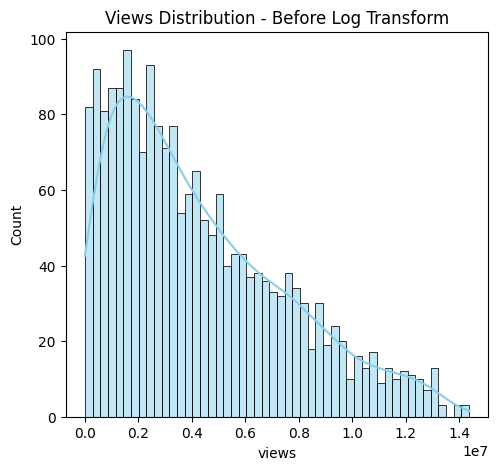

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['views'], bins=50, kde=True, color='skyblue')
plt.title("Views Distribution - Before Log Transform")
plt.show()


Log Transformation (Reduce Skewness)

In [20]:
df['views'] = np.log1p(df['views'])
df['likes'] = np.log1p(df['likes'])
df['shares'] = np.log1p(df['shares'])
df['comments'] = np.log1p(df['comments'])

Visualize Distribution After Log Transformation

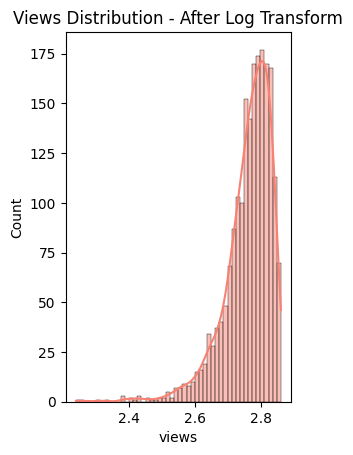

In [21]:
plt.subplot(1,2,2)
sns.histplot(np.log1p(df['views']), bins=50, kde=True, color='salmon')
plt.title("Views Distribution - After Log Transform")
plt.show()

## Exploratory Data Analysis

### Correlation Analysis

Correlation Matrix

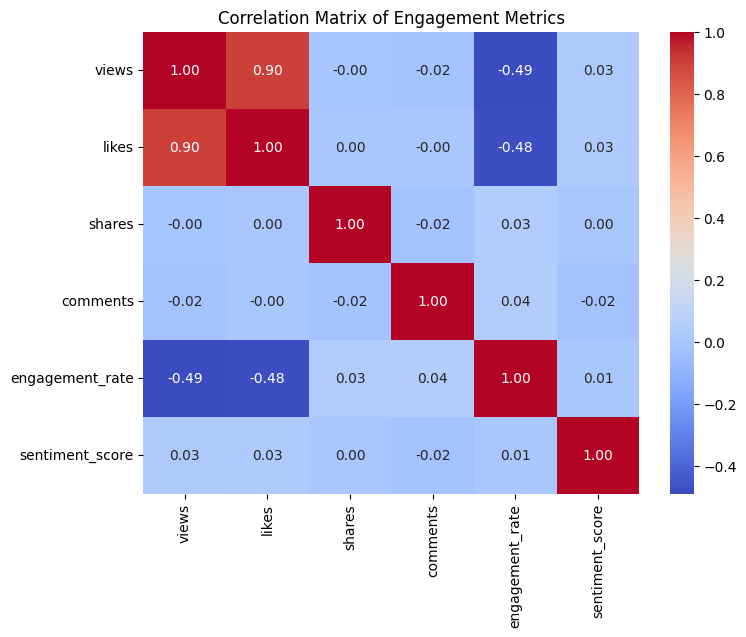

In [25]:
corr = df[['views','likes','shares','comments','engagement_rate','sentiment_score']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Engagement Metrics")
plt.show()

 Correlation with views only

In [26]:
corr_with_views = corr['views'].sort_values(ascending=False)
print(corr_with_views)

views              1.000000
likes              0.898881
sentiment_score    0.025825
shares            -0.001535
comments          -0.015247
engagement_rate   -0.489375
Name: views, dtype: float64


Scatter Plots to visualize relationships

Likes vs Views

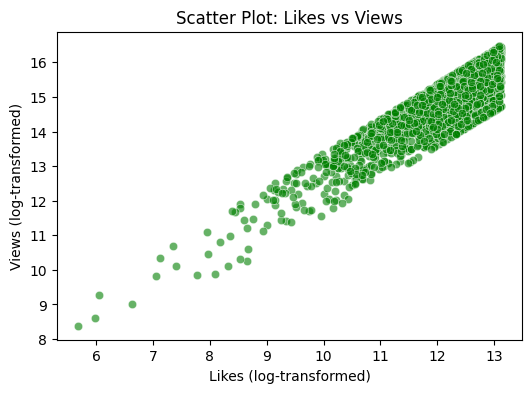

In [27]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='likes', y='views', data=df, alpha=0.6, color='green')
plt.title("Scatter Plot: Likes vs Views")
plt.xlabel("Likes (log-transformed)")
plt.ylabel("Views (log-transformed)")
plt.show()

Shares vs Views

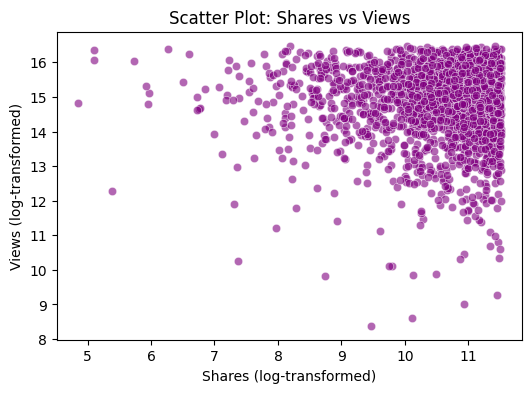

In [28]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='shares', y='views', data=df, alpha=0.6, color='purple')
plt.title("Scatter Plot: Shares vs Views")
plt.xlabel("Shares (log-transformed)")
plt.ylabel("Views (log-transformed)")
plt.show()

## Pearson Correlation Test

In [29]:
r, p = stats.pearsonr(df['likes'], df['views'])
print(f"Likes → Correlation: {r:.4f}, p-value: {p:.4f}")

Likes → Correlation: 0.8989, p-value: 0.0000


## Regression Model (Views ~ Likes)

In [30]:
model_likes = smf.ols('views ~ likes', data=df).fit()
print(model_likes.summary())

                            OLS Regression Results                            
Dep. Variable:                  views   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     8408.
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        12:01:35   Log-Likelihood:                -1379.7
No. Observations:                2000   AIC:                             2763.
Df Residuals:                    1998   BIC:                             2775.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.7840      0.132     21.069      0.0

# Optional Residual Plot

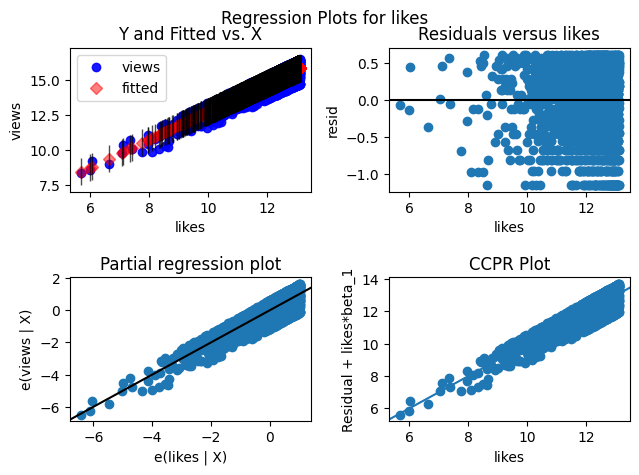

In [32]:
sm.graphics.plot_regress_exog(model_likes, 'likes')
plt.show()